In [1]:
import numpy as np
import matplotlib.pyplot as plt
import string
import os
from matplotlib.lines import Line2D

plt.rcParams.update(
    {
        "font.size": 9,  # base font size (tick labels)
        "axes.labelsize": 9,  # axis labels
        "axes.titlesize": 9,
        "legend.fontsize": 9,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "figure.dpi": 300,
    }
)

import jax.numpy as jnp
import jax

jax.config.update("jax_enable_x64", True)
jax.config.update("jax_default_device", jax.devices("cpu")[0])

# Import your optimization and plotting utilities
from optimization_core import (
    build_jsa_grid,
    penalty_continuation_grad_desc,
    load_results,
    to_complex,
)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


In [2]:
datag = jnp.load("lo_distr_gaussian_3D.npz", allow_pickle=True)

omf_g = datag["omf"]
u_g = datag["u"]  # this is your u_array
s_g = datag["s"]  # your s_array
lo_optim_g = datag["lo_optim"]  # your lo_optim_array

In [3]:
datah = jnp.load("lo_distr_hopdc_3D.npz", allow_pickle=True)

omf_h = datah["omf"]
u_h = datah["u"]  # this is your u_array
s_h = datah["s"]  # your s_array
lo_optim_h = datah["lo_optim"]  # your lo_optim_array

/home/gisell/miniconda3/envs/tensor_lo_optim/lib/python3.14/site-packages/matplotlib/cbook.py:1810: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/gisell/miniconda3/envs/tensor_lo_optim/lib/python3.14/site-packages/matplotlib/cbook.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asanyarray(x, float)


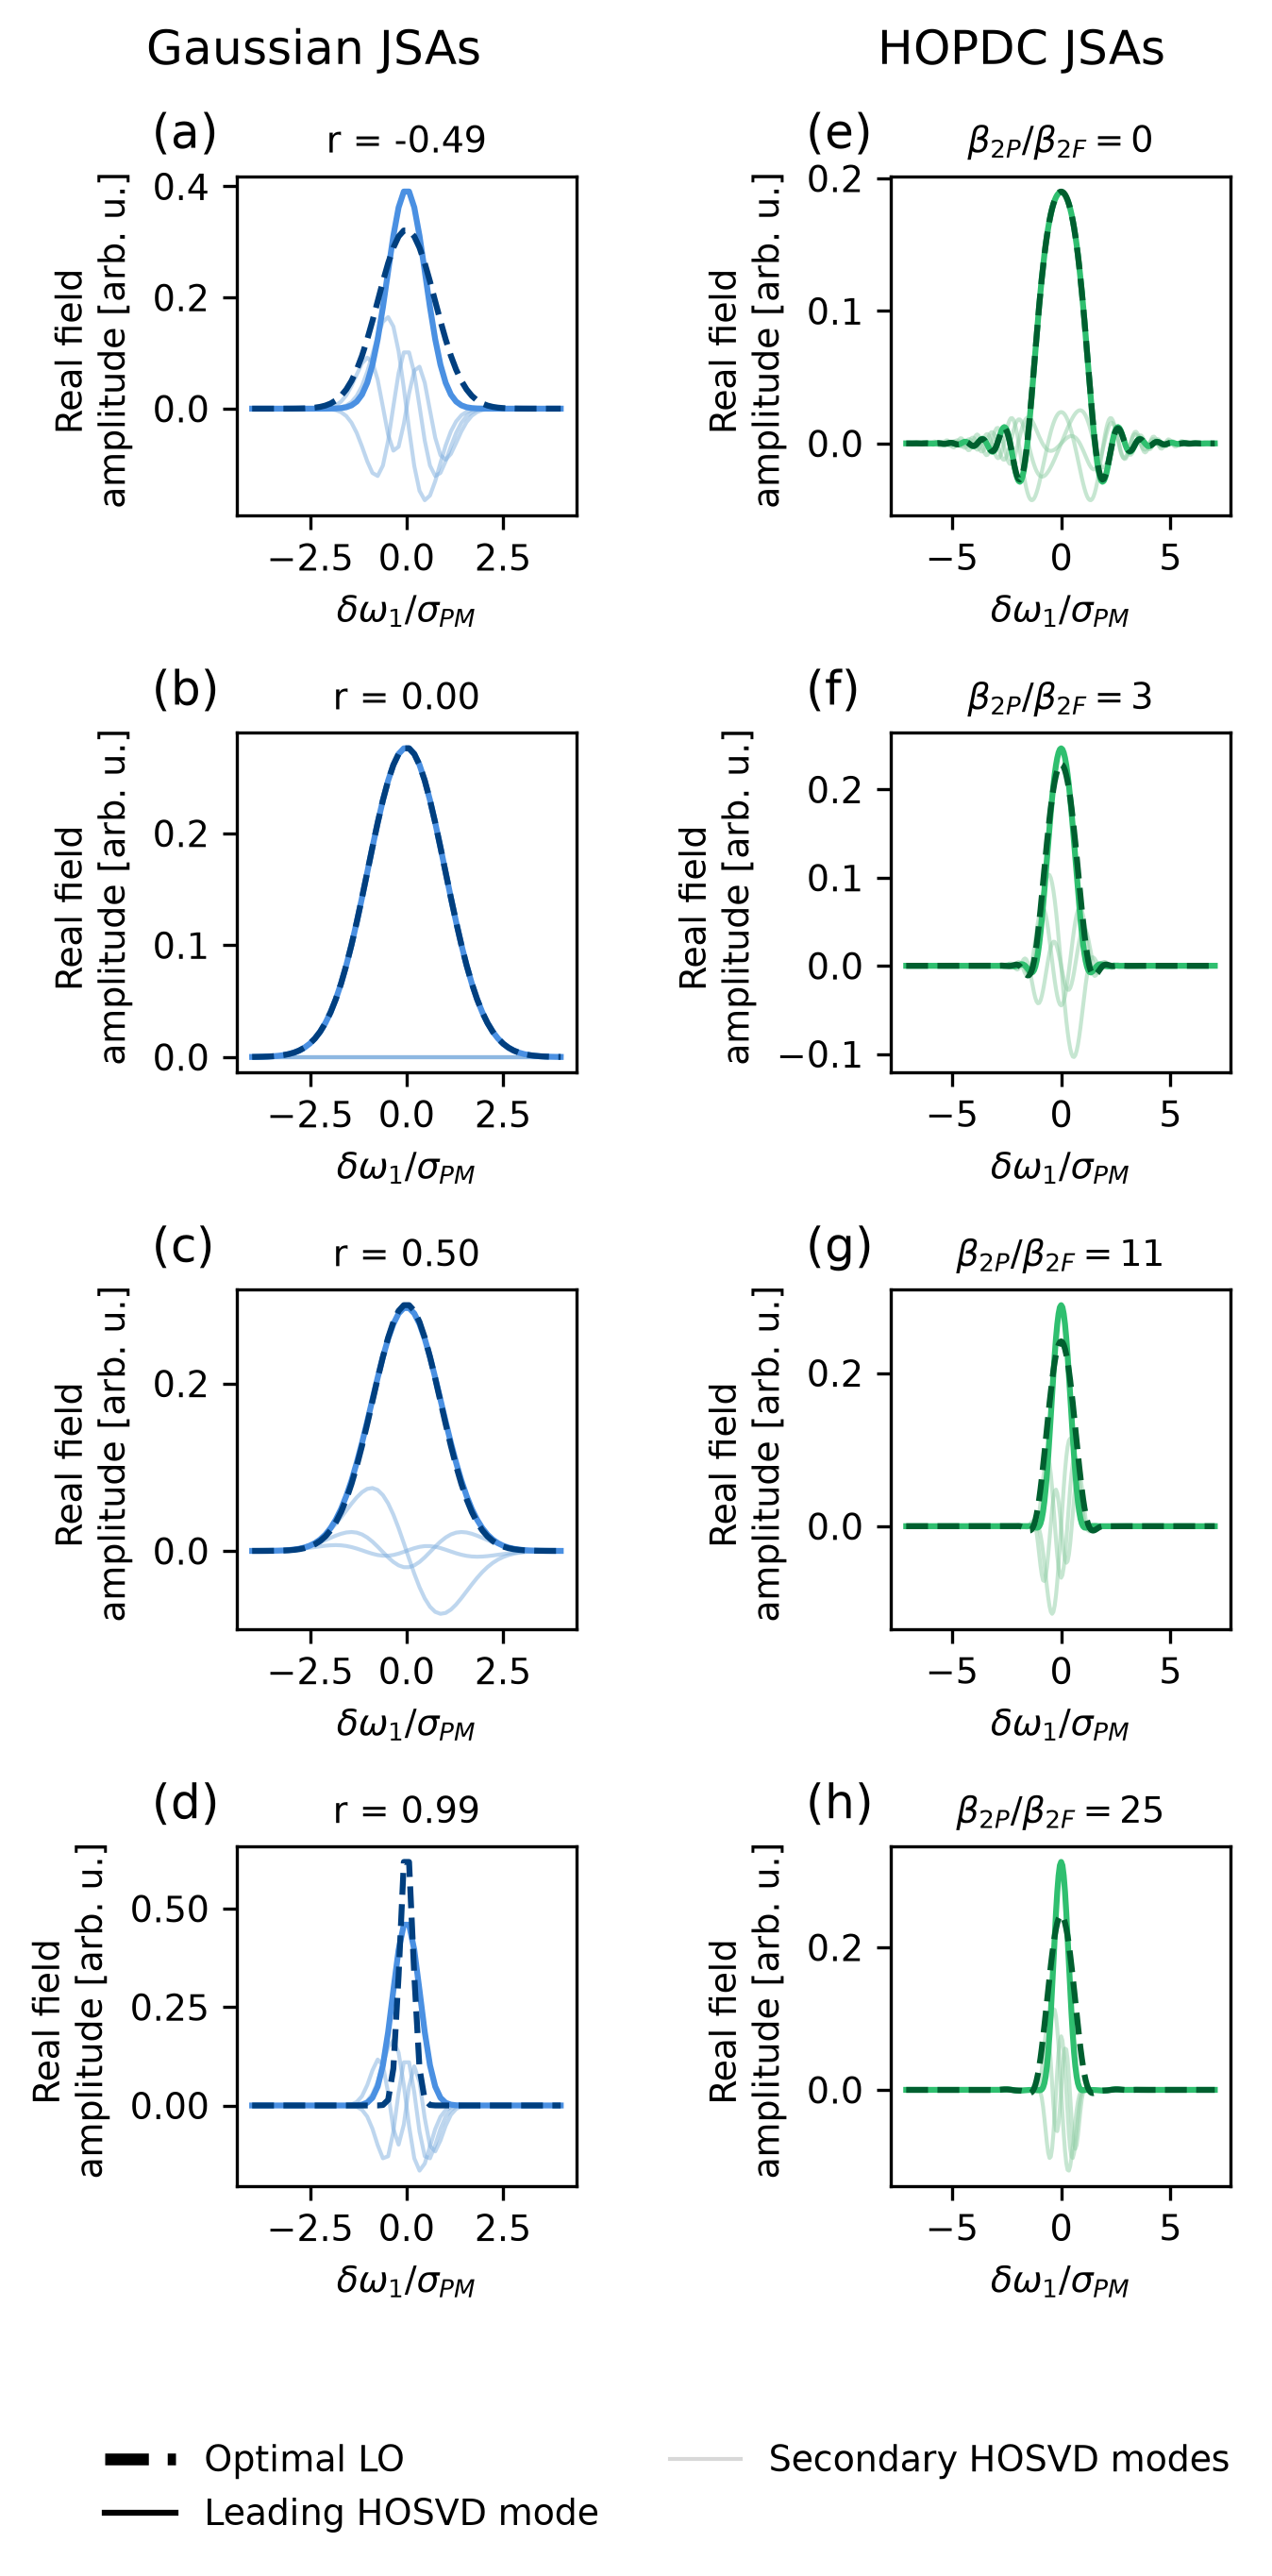

In [4]:
n_col = 2  # Number of columns in the figure
rho_values = jnp.array([0, 1, 2, 3])
fig, axes = plt.subplots(
    len(rho_values), n_col, figsize=(2.5 * n_col, n_col * len(rho_values))
)


fig.subplots_adjust(hspace=0.35)  # try 0.3–0.6 depending on your labels


# Generate labels: a, b, c, ...
labels = list(string.ascii_lowercase)

# Define your blue tones
blue_main = "#4A90E2"  # strong blue for lo_optim
blue_dark = "#003F7F"  # darker blue for u[0]
blue_light = "#7FAFDF"  # light blue for the rest

# Define your green tones
green_main = "#2FBF6F"  # strong green for lo_optim
green_dark = "#005F2F"  # darker green for u[0]
green_light = "#8FCEA5"  # light green for the rest

titleg = jnp.array([-0.49, 0, 0.50, 0.99])
titleh = jnp.array([0, 3, 11, 25])

for i, rho in enumerate(rho_values):
    # Plot

    ax0 = axes[i, 0]

    for j in range(1, 4):
        ax0.plot(
            omf_g,
            -1 * s_g[i][j] * u_g[i][:, j] / jnp.linalg.norm(u_g[i][:, j]),
            color=blue_light,
            alpha=0.5,
            linewidth=1,
        )
    ui = u_g[i][:, 0]
    sign_factor = 1 if ui.max() > 0 else -1
    ax0.plot(omf_g, sign_factor * ui / jnp.linalg.norm(ui), color=blue_main)
    ax0.plot(omf_g, lo_optim_g[i], rasterized=True, color=blue_dark, linestyle="--")

    tg = titleg[i]
    ax0.set_title(rf"r = {tg:.2f}")
    ax0.set_box_aspect(1)
    ax0.set_xlabel(r"$\delta\omega_{1}/\sigma_{PM}$")
    ax0.set_ylabel(f"Real field \n amplitude [arb. u.]")

    # compute label index for column-major order
    j = 0
    label_idx = i + j * len(rho_values)
    # Add label outside the plot
    ax0.text(
        -0.25,
        1.05,
        f"({labels[label_idx]})",
        transform=ax0.transAxes,
        fontsize=12,
        va="bottom",
        ha="left",
    )

    ax1 = axes[i, 1]

    for j in range(1, 4):
        ax1.plot(
            omf_h,
            -1 * s_h[i][j] * u_h[i][:, j] / jnp.linalg.norm(u_h[i][:, j]),
            color=green_light,
            alpha=0.5,
            linewidth=1,
        )

    uih = u_h[i][:, 0]
    idx = jnp.argmax(jnp.abs(uih))  # index of largest |amplitude|
    peak_value = uih[idx]  # actual signed amplitude
    sign_factor_h = 1 if peak_value > 0 else -1
    ax1.plot(omf_h, sign_factor_h * uih / jnp.linalg.norm(uih), color=green_main)
    ax1.plot(omf_h, lo_optim_h[i], rasterized=True, color=green_dark, linestyle="--")

    th = titleh[i]
    ax1.set_title(rf"$\beta_{{2P}}/\beta_{{2F}} = {th:.0f}$")
    ax1.set_box_aspect(1)
    ax1.set_xlabel(r"$\delta\omega_{1}/\sigma_{PM}$")
    ax1.set_ylabel(f"Real field \n amplitude [arb. u.]")

    # compute label index for column-major order
    j = 1
    label_idx = i + j * len(rho_values)
    # Add label outside the plot
    ax1.text(
        -0.25,
        1.05,
        f"({labels[label_idx]})",
        transform=ax1.transAxes,
        fontsize=12,
        va="bottom",
        ha="left",
    )


legend_elements = [
    Line2D([0], [0], color="black", lw=3, linestyle="--", label="Optimal LO"),
    Line2D([0], [0], color="black", lw=1.5, label="Leading HOSVD mode"),
    Line2D([0], [0], color="gray", lw=1, alpha=0.3, label="Secondary HOSVD modes"),
]

fig.text(0.25, 1.02, "Gaussian JSAs", ha="center", va="top", fontsize=12)
fig.text(0.75, 1.02, "HOPDC JSAs", ha="center", va="top", fontsize=12)


fig.legend(
    handles=legend_elements,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.1),
    ncol=2,
    frameon=False,
)
plt.tight_layout()


plt.savefig(f"lo_distributions.pdf", dpi=300, bbox_inches="tight")
plt.show()